In [ ]:
!pip install -q sentence-transformers==2.7.0 scikit-learn==1.4.2 matplotlib seaborn scipy
print("Install done — now restart runtime before continuing.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 146.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
Install done — now restart runtime before continuing.


In [ ]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.constrained_layout.use': True,
})

print('numpy :', np.__version__)
print('torch :', torch.__version__)
print('cuda  :', torch.cuda.is_available())


numpy : 2.0.2
torch : 2.10.0+cu128
cuda  : True


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
EN_DIR     = Path('/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed')
RU_DIR     = Path('/content/drive/MyDrive/medical_protocols/gold_standard_md')
OUTPUT_DIR = Path('/content/drive/MyDrive/medical_protocols/embeddings/section_embeddings_v1')
RU_EMB_DIR = Path('/content/drive/MyDrive/medical_protocols/ru_embeddings')   # for comparison
PLOT_DIR   = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

MIN_CHARS  = 200      # must match RU pipeline
N_CLUSTERS = 12       # primary k for KMeans
K_RANGE    = range(4, 21)
BATCH_SIZE = 16       # smaller than RU due to larger model
TSNE_PERP  = 40

EN_MODEL_NAME = 'NeuML/bioclinical-modernbert-base-embeddings'
RU_MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'

print(f'EN_DIR     : {EN_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'MIN_CHARS  : {MIN_CHARS}  <- must equal RU pipeline')
print(f'N_CLUSTERS : {N_CLUSTERS}')
print(f'EN model   : {EN_MODEL_NAME}')

EN_DIR     : /content/drive/MyDrive/medical_protocols/en_aux_v1_fixed
OUTPUT_DIR : /content/drive/MyDrive/medical_protocols/embeddings/section_embeddings_v1
MIN_CHARS  : 200  <- must equal RU pipeline
N_CLUSTERS : 12
EN model   : NeuML/bioclinical-modernbert-base-embeddings


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = SentenceTransformer(EN_MODEL_NAME, device=device)
print(f'Model : {EN_MODEL_NAME}')
print(f'Device: {device}')

test_vec = model.encode(['test sentence'], convert_to_numpy=True)
print(f'Embedding dim: {test_vec.shape[1]}')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/205 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Model : NeuML/bioclinical-modernbert-base-embeddings
Device: cuda
Embedding dim: 768


In [ ]:
def split_markdown_sections(md_text: str, min_chars: int = 200):
    """
    Split a Markdown document by ## headers.
    Returns list of (title: str, body: str) tuples where len(body) >= min_chars.
    Identical logic to RU pipeline for comparability.
    """
    md_text = md_text.replace('\r\n', '\n').strip()
    parts   = re.split(r'(?=^##\s+)', md_text, flags=re.M)
    out     = []
    for part in parts:
        part = part.strip()
        if not part:
            continue
        lines = part.splitlines()
        if lines and lines[0].startswith('##'):
            title = lines[0].lstrip('#').strip()
            body  = '\n'.join(lines[1:]).strip()
        else:
            title = 'NO_HEADER'
            body  = part
        if len(body) >= min_chars:
            out.append((title, body))
    return out


# ── Corpus scan (before embedding) ───────────────────────────────────────────
en_files = sorted(EN_DIR.glob('en_*.md'))
print(f'EN protocol files found: {len(en_files)}')

section_counts = []
for fp in en_files:
    txt = fp.read_text(encoding='utf-8', errors='ignore')
    n   = len(split_markdown_sections(txt, min_chars=MIN_CHARS))
    section_counts.append({'file': fp.name, 'n_sections': n})

df_counts = pd.DataFrame(section_counts)
print(f'\nSection count stats (min_chars={MIN_CHARS}):')
print(df_counts['n_sections'].describe().round(1).to_string())
print(f'\nTotal sections: {df_counts["n_sections"].sum()}')

EN protocol files found: 84

Section count stats (min_chars=200):
count     84.0
mean      24.2
std       22.7
min        3.0
25%       13.0
50%       19.0
75%       27.2
max      145.0

Total sections: 2029


In [ ]:
all_vecs = []
all_rows = []

for fp in tqdm(en_files, desc='Embedding EN sections'):
    pt_path   = OUTPUT_DIR / f'sections_{fp.stem}.pt'
    meta_path = OUTPUT_DIR / f'sections_{fp.stem}.json'

    text     = fp.read_text(encoding='utf-8', errors='ignore')
    sections = split_markdown_sections(text, min_chars=MIN_CHARS)
    if not sections:
        continue

    titles = [t for t, _ in sections]
    bodies = [b for _, b in sections]

    if pt_path.exists() and meta_path.exists():
        embs_cpu = torch.load(pt_path, map_location='cpu')
    else:
        embs     = model.encode(bodies, convert_to_tensor=True,
                                batch_size=BATCH_SIZE, show_progress_bar=False)
        embs_cpu = embs.detach().cpu()
        torch.save(embs_cpu, pt_path)
        meta = {
            'file': fp.name,
            'section_count': len(sections),
            'titles': titles,
            'char_lengths': [len(b) for b in bodies],
        }
        meta_path.write_text(
            json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8'
        )

    for i, (title, body) in enumerate(sections):
        all_vecs.append(embs_cpu[i])
        all_rows.append({
            'file':          fp.name,
            'protocol':      fp.stem.replace('en_', ''),
            'section_id':    i,
            'section_title': title,
            'section_chars': len(body),
            'text_preview':  body[:300],
        })

X  = torch.stack(all_vecs).numpy()   # (n_sections, emb_dim)
df = pd.DataFrame(all_rows)
print(f'Total sections  : {len(df)}')
print(f'Embedding matrix: {X.shape}')

Embedding EN sections: 100%|██████████| 84/84 [00:23<00:00,  3.51it/s]

Total sections  : 2029
Embedding matrix: (2029, 768)


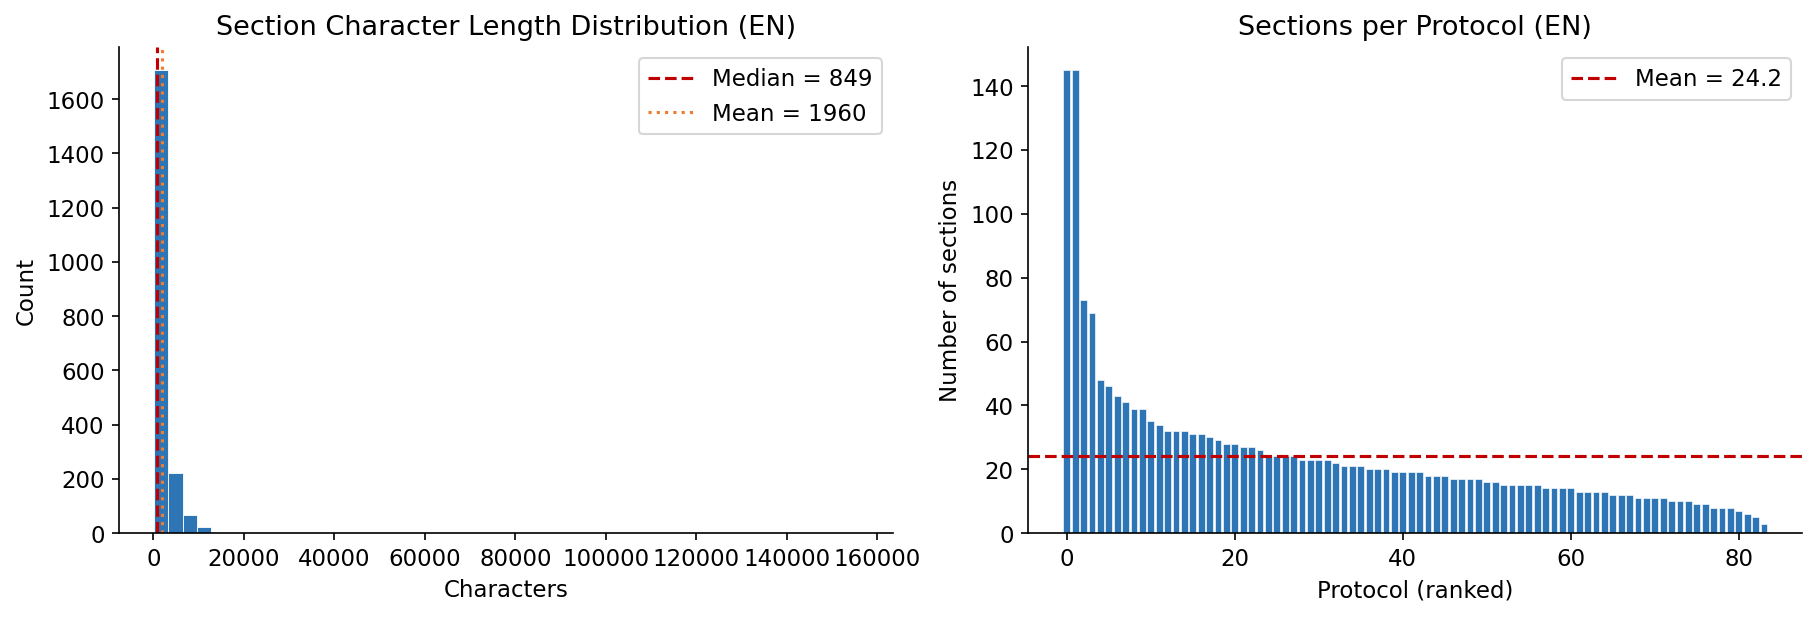


EN corpus statistics:


,chars
count,2029.0
mean,1959.6
std,5420.4
min,200.0
25%,401.0
50%,849.0
75%,2272.0
max,155806.0
total_sections,2029.0
n_protocols,84.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['section_chars'], bins=50, color='#2E75B6',
             edgecolor='white', linewidth=0.4)
axes[0].axvline(df['section_chars'].median(), color='#C00000', linewidth=1.5,
                linestyle='--', label=f'Median = {df["section_chars"].median():.0f}')
axes[0].axvline(df['section_chars'].mean(), color='#ED7D31', linewidth=1.5,
                linestyle=':', label=f'Mean = {df["section_chars"].mean():.0f}')
axes[0].set_title('Section Character Length Distribution (EN)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')
axes[0].legend()

spp = df.groupby('protocol')['section_id'].count().sort_values(ascending=False)
axes[1].bar(range(len(spp)), spp.values, color='#2E75B6',
            edgecolor='white', linewidth=0.3)
axes[1].axhline(spp.mean(), color='#C00000', linewidth=1.5, linestyle='--',
                label=f'Mean = {spp.mean():.1f}')
axes[1].set_title('Sections per Protocol (EN)')
axes[1].set_xlabel('Protocol (ranked)')
axes[1].set_ylabel('Number of sections')
axes[1].legend()

fig.savefig(PLOT_DIR / 'fig_en_section_length_distribution.png', bbox_inches='tight')
plt.show()

stats = df['section_chars'].describe().rename('chars').to_frame()
stats.loc['total_sections'] = len(df)
stats.loc['n_protocols']    = df['protocol'].nunique()
print('\nEN corpus statistics:')
display(stats.round(1))

Sweeping k from 4 to 20...


k sweep: 100%|██████████| 17/17 [00:05<00:00,  3.20it/s]


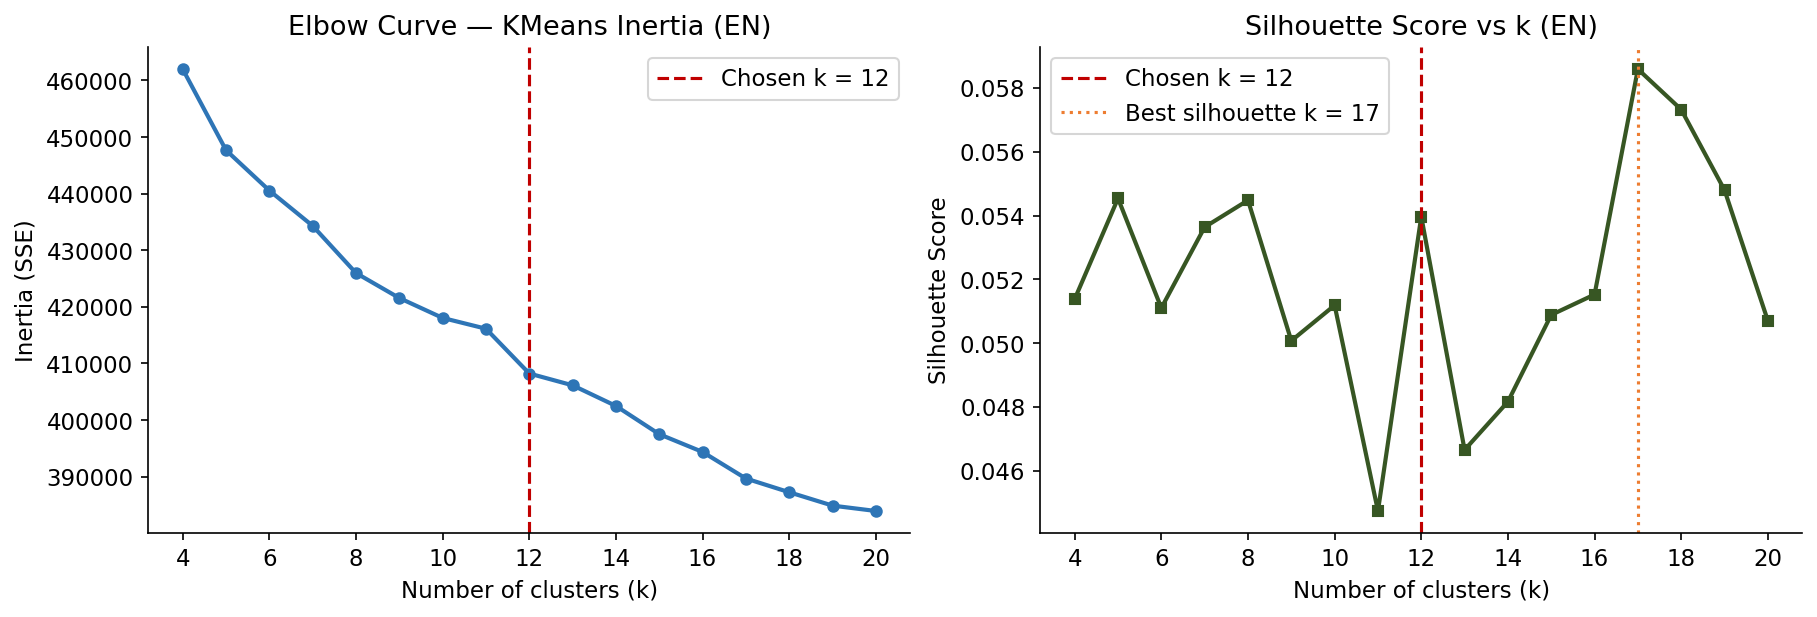

Best silhouette k = 17  (score = 0.0586)
Chosen k          = 12  (score = 0.0540)


In [ ]:
inertias   = []
sil_scores = []
k_list     = list(K_RANGE)

print(f'Sweeping k from {k_list[0]} to {k_list[-1]}...')
for k in tqdm(k_list, desc='k sweep'):
    km  = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_list, inertias, 'o-', color='#2E75B6', linewidth=2, markersize=5)
axes[0].axvline(N_CLUSTERS, color='#C00000', linewidth=1.5,
                linestyle='--', label=f'Chosen k = {N_CLUSTERS}')
axes[0].set_title('Elbow Curve — KMeans Inertia (EN)')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].legend()

best_k = k_list[int(np.argmax(sil_scores))]
axes[1].plot(k_list, sil_scores, 's-', color='#375623', linewidth=2, markersize=5)
axes[1].axvline(N_CLUSTERS, color='#C00000', linewidth=1.5,
                linestyle='--', label=f'Chosen k = {N_CLUSTERS}')
axes[1].axvline(best_k, color='#ED7D31', linewidth=1.5,
                linestyle=':', label=f'Best silhouette k = {best_k}')
axes[1].set_title('Silhouette Score vs k (EN)')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

fig.savefig(PLOT_DIR / 'fig_en_optimal_k_sweep.png', bbox_inches='tight')
plt.show()

print(f'Best silhouette k = {best_k}  (score = {max(sil_scores):.4f})')
print(f'Chosen k          = {N_CLUSTERS}  (score = {sil_scores[k_list.index(N_CLUSTERS)]:.4f})')

In [ ]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init='auto')
labels = kmeans.fit_predict(X)
df['cluster'] = labels

sil_global     = silhouette_score(X, labels)
sil_per_sample = silhouette_samples(X, labels)
df['silhouette_sample'] = sil_per_sample

print(f'Global silhouette score (k={N_CLUSTERS}): {sil_global:.4f}')
print('\nPer-cluster silhouette:')
sil_by_cluster = (
    df.groupby('cluster')['silhouette_sample']
    .agg(['mean', 'median', 'std'])
    .round(4)
    .sort_values('mean', ascending=False)
)
display(sil_by_cluster)

out_csv = OUTPUT_DIR / 'clusters_sections.csv'
df.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}')

Global silhouette score (k=12): 0.0540

Per-cluster silhouette:


,mean,median,std
cluster,,,
1,0.2164,0.2287,0.0757
9,0.1571,0.1468,0.0658
6,0.0764,0.0660,0.0563
10,0.0719,0.0713,0.0339
5,0.0665,0.0605,0.0439
3,0.0613,0.0578,0.0456
4,0.0499,0.0489,0.0400
7,0.0461,0.0450,0.0339
2,0.0393,0.0378,0.0366



Saved: /content/drive/MyDrive/medical_protocols/embeddings/section_embeddings_v1/clusters_sections.csv


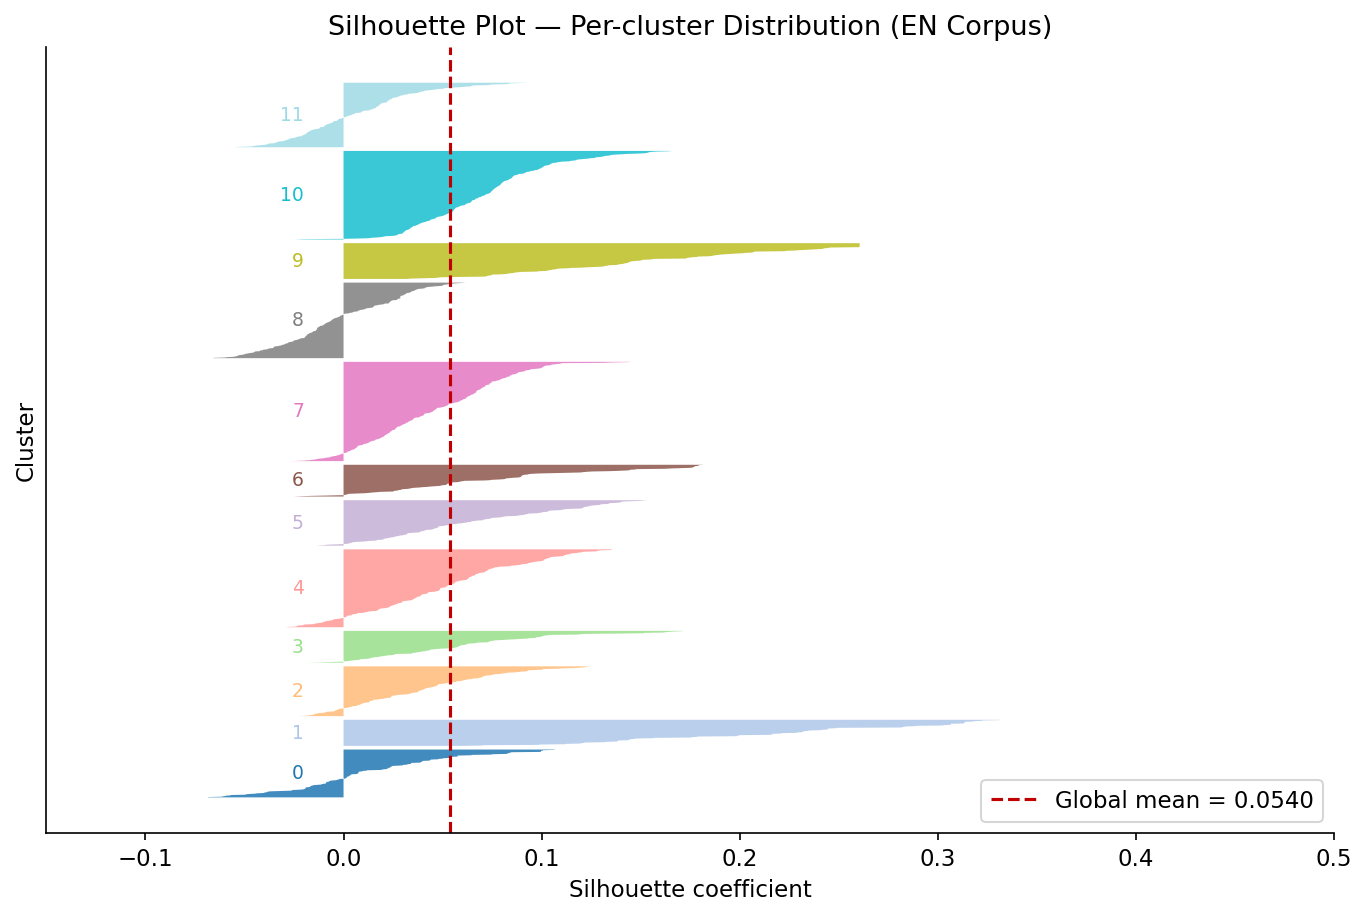

In [ ]:
cluster_ids = sorted(df['cluster'].unique())
colors      = plt.cm.tab20(np.linspace(0, 1, len(cluster_ids)))

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
for idx, c in enumerate(cluster_ids):
    sil_vals = np.sort(sil_per_sample[labels == c])
    size_c   = len(sil_vals)
    y_upper  = y_lower + size_c
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_vals,
                     facecolor=colors[idx], edgecolor='none', alpha=0.85)
    ax.text(-0.02, y_lower + 0.5 * size_c, str(c),
            va='center', ha='right', fontsize=9, color=colors[idx])
    y_lower = y_upper + 10

ax.axvline(sil_global, color='#C00000', linewidth=1.5, linestyle='--',
           label=f'Global mean = {sil_global:.4f}')
ax.set_title('Silhouette Plot — Per-cluster Distribution (EN Corpus)')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend(loc='lower right')
ax.set_xlim(-0.15, 0.5)
fig.savefig(PLOT_DIR / 'fig_en_silhouette_plot.png', bbox_inches='tight')
plt.show()

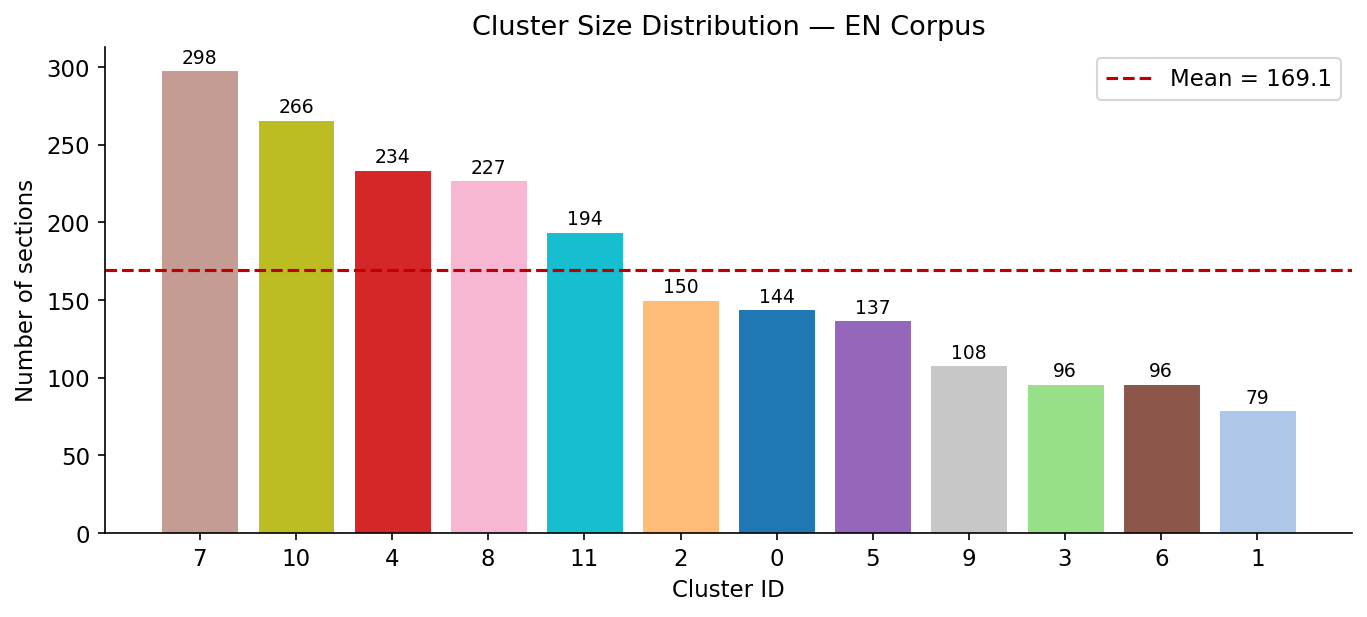

,cluster,n_sections
7,7,298
10,10,266
4,4,234
8,8,227
11,11,194
2,2,150
0,0,144
5,5,137
9,9,108
3,3,96


In [ ]:
cluster_sizes = (
    df.groupby('cluster').size()
    .reset_index(name='n_sections')
    .sort_values('n_sections', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    cluster_sizes['cluster'].astype(str),
    cluster_sizes['n_sections'],
    color=[plt.cm.tab20(i / N_CLUSTERS) for i in cluster_sizes.index],
    edgecolor='white', linewidth=0.5,
)
ax.axhline(cluster_sizes['n_sections'].mean(), color='#C00000',
           linestyle='--', linewidth=1.5,
           label=f'Mean = {cluster_sizes["n_sections"].mean():.1f}')
for bar, val in zip(bars, cluster_sizes['n_sections']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=9)
ax.set_title('Cluster Size Distribution — EN Corpus')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Number of sections')
ax.legend()
fig.savefig(PLOT_DIR / 'fig_en_cluster_sizes.png', bbox_inches='tight')
plt.show()
display(cluster_sizes)

In [ ]:
TOP_N = 8
title_rows = []
for c in sorted(df['cluster'].unique()):
    top = df[df['cluster'] == c]['section_title'].value_counts().head(TOP_N)
    for title, cnt in top.items():
        title_rows.append({'cluster': int(c), 'section_title': title, 'count': int(cnt)})

df_titles = pd.DataFrame(title_rows)
df_titles.to_csv(OUTPUT_DIR / 'cluster_top_titles.csv', index=False)

for c in sorted(df['cluster'].unique()):
    sub = df_titles[df_titles['cluster'] == c]
    print(f'\nCluster {c:>2}  (n={len(df[df["cluster"]==c])} sections)')
    print('  ' + ', '.join(sub['section_title'].tolist()))


Cluster  0  (n=144 sections)
  2.2 Contraindications to the procedure and intervention:, 1.1 ICD-10 Code(s):, 2.6 Indicators of procedure effectiveness:, 2.4 List of Main and Additional Diagnostic Procedures:, 2.1 Purpose of the procedure and intervention:, 2.3 Indications for the procedure and intervention:, 2.5 Requirements for conducting procedure and intervention:, 1.3 Abbreviations used in the protocol:

Cluster  1  (n=79 sections)
  2.6 Indicators of procedure effectiveness:, 2.2 Contraindications to the procedure and intervention:, 2.1 Purpose of the procedure and intervention:, 2.4 List of Main and Additional Diagnostic Procedures:, 2.5 Requirements for conducting procedure and intervention:, 2.4 List of main and additional diagnostic procedures:, 2.3 Indications for the procedure and intervention:, 1.7 Clinical Classification (most common approaches by etiology, stage)

Cluster  2  (n=150 sections)
  Laboratory Research:, 4. Abbreviations used in the protocol:, Instrumental R

In [ ]:
CLUSTER_LABELS = {
    0:  'Diagnosis & Criteria',
    1:  'Pharmacotherapy',
    2:  'Surgical Procedures',
    3:  'Antenatal Monitoring',
    4:  'Risk Stratification',
    5:  'Laboratory Tests',
    6:  'Patient Management',
    7:  'Postpartum Care',
    8:  'Infection & Sepsis',
    9:  'Oncology Protocols',
    10: 'Screening & Prevention',
    11: 'Emergency Procedures',
}

df['cluster_label'] = df['cluster'].map(CLUSTER_LABELS)
print('Cluster labels applied.')
display(
    df.groupby(['cluster', 'cluster_label'])
    .size()
    .reset_index(name='n_sections')
)

Cluster labels applied.


,cluster,cluster_label,n_sections
0,0,Diagnosis & Criteria,144
1,1,Pharmacotherapy,79
2,2,Surgical Procedures,150
3,3,Antenatal Monitoring,96
4,4,Risk Stratification,234
5,5,Laboratory Tests,137
6,6,Patient Management,96
7,7,Postpartum Care,298
8,8,Infection & Sepsis,227
9,9,Oncology Protocols,108


In [ ]:
print(f'Running t-SNE (perplexity={TSNE_PERP})... may take 2-3 min')
tsne = TSNE(n_components=2, perplexity=TSNE_PERP, random_state=SEED,
            n_iter=1000, metric='cosine', init='pca')
X_2d = tsne.fit_transform(X)
df['tsne_x'] = X_2d[:, 0]
df['tsne_y'] = X_2d[:, 1]
np.save(OUTPUT_DIR / 'en_tsne_coords.npy', X_2d)
print('t-SNE done.')

Running t-SNE (perplexity=40)... may take 2-3 min
t-SNE done.


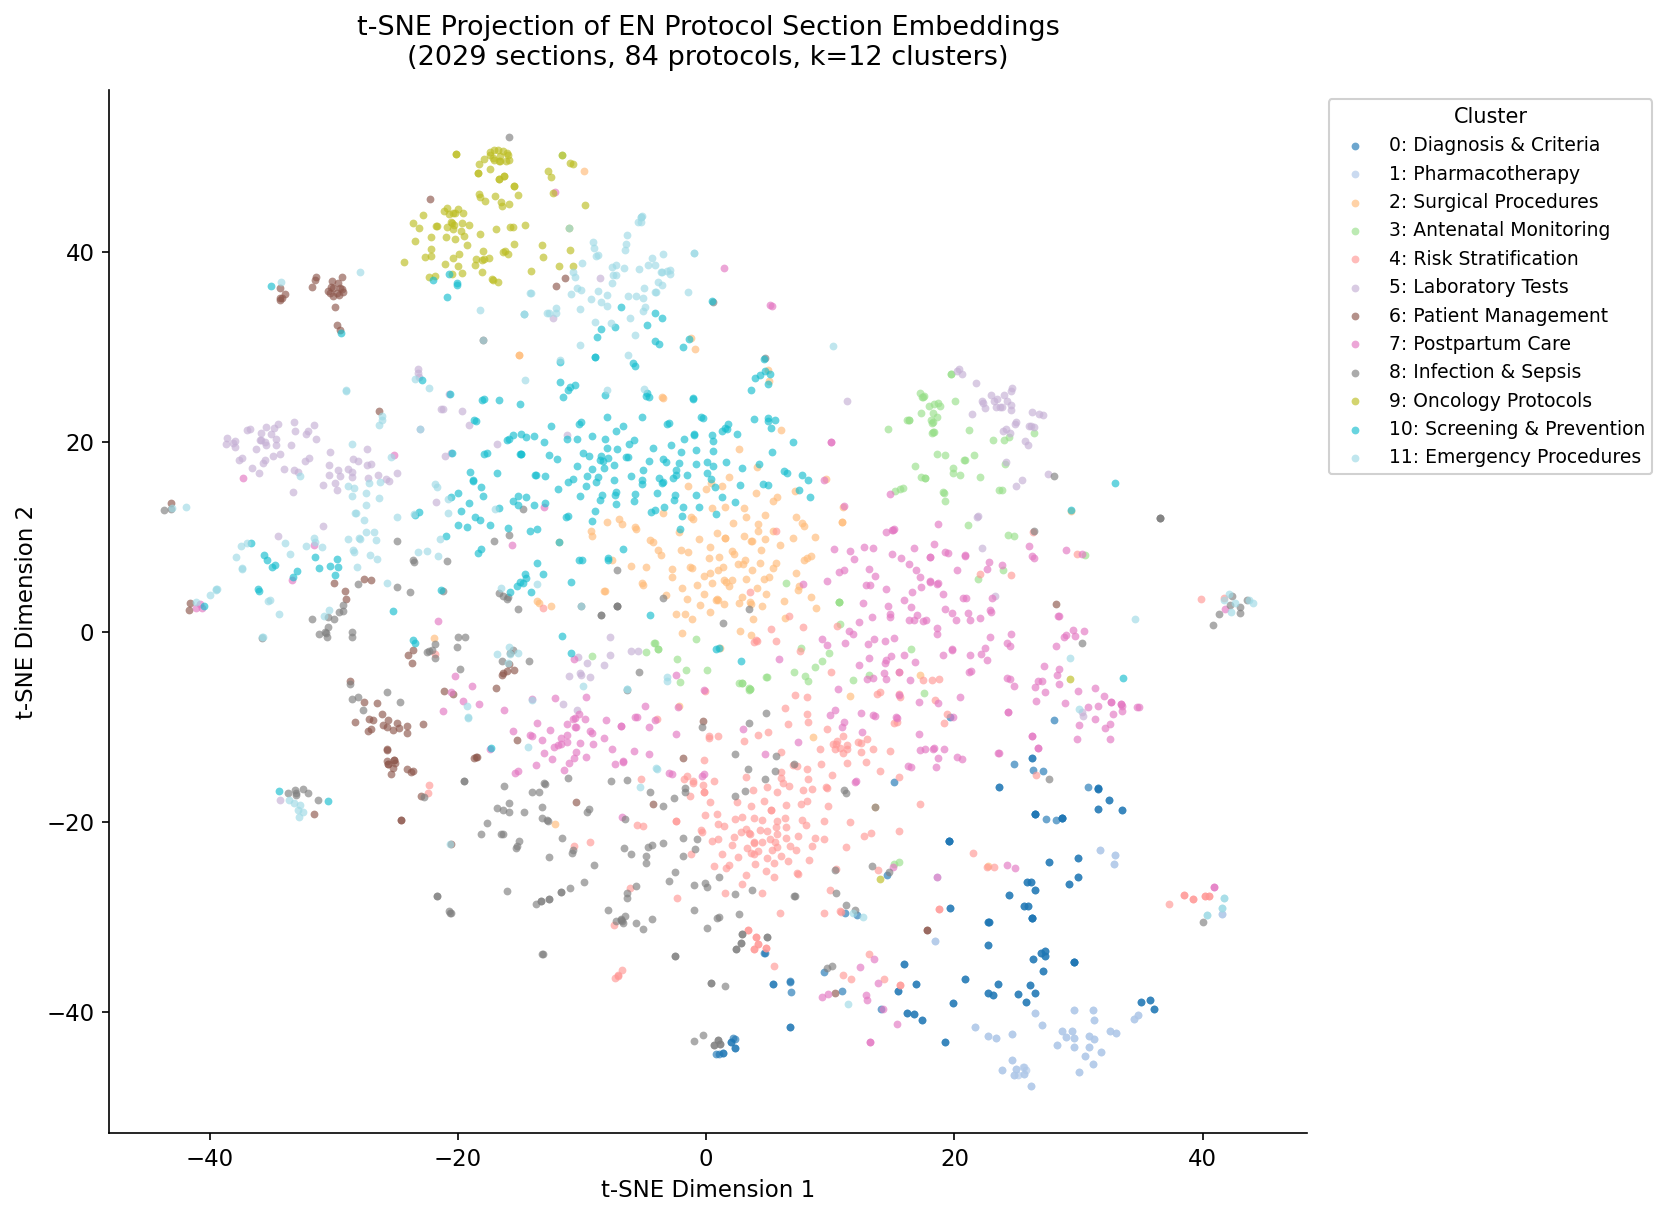

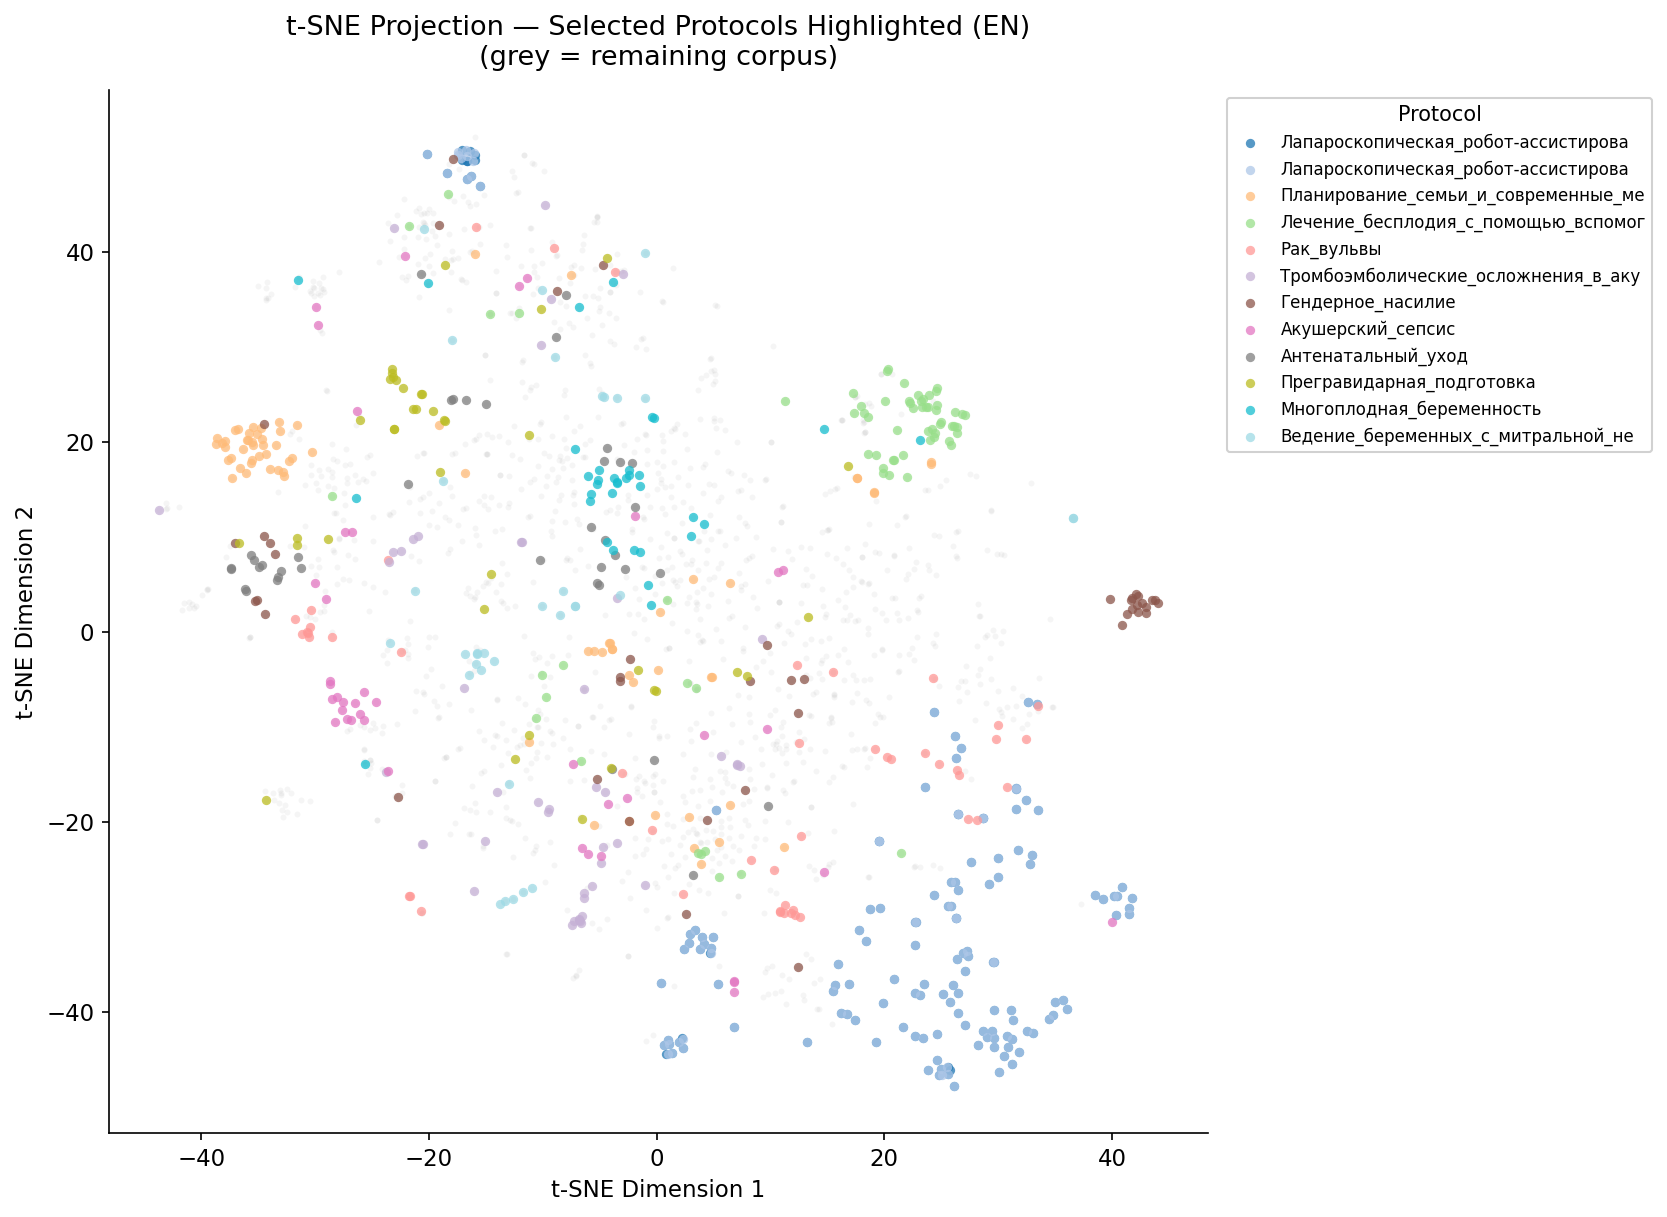

In [ ]:
# ── Figure A: by cluster ──────────────────────────────────────────────────────
colors = plt.cm.tab20(np.linspace(0, 1, N_CLUSTERS))
fig, ax = plt.subplots(figsize=(11, 8))
for c in sorted(df['cluster'].unique()):
    mask  = df['cluster'] == c
    label = CLUSTER_LABELS.get(c, f'Cluster {c}')
    ax.scatter(df.loc[mask, 'tsne_x'], df.loc[mask, 'tsne_y'],
               s=14, alpha=0.65, color=colors[c],
               label=f'{c}: {label}', linewidths=0)
ax.set_title(
    't-SNE Projection of EN Protocol Section Embeddings\n'
    f'({len(df)} sections, {df["protocol"].nunique()} protocols, k={N_CLUSTERS} clusters)',
    pad=12
)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, title_fontsize=10, framealpha=0.9)
fig.savefig(PLOT_DIR / 'fig_en_tsne_clusters.png', bbox_inches='tight')
plt.show()

top_protocols   = df['protocol'].value_counts().head(12).index.tolist()
df_sub          = df[df['protocol'].isin(top_protocols)].copy()
p_colors        = plt.cm.tab20(np.linspace(0, 1, len(top_protocols)))
p_color_map     = {p: p_colors[i] for i, p in enumerate(top_protocols)}

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(df['tsne_x'], df['tsne_y'], s=8, alpha=0.08, color='grey', linewidths=0)
for proto in top_protocols:
    mask = df_sub['protocol'] == proto
    ax.scatter(df_sub.loc[mask, 'tsne_x'], df_sub.loc[mask, 'tsne_y'],
               s=20, alpha=0.75, color=p_color_map[proto],
               label=proto[:35], linewidths=0)
ax.set_title('t-SNE Projection — Selected Protocols Highlighted (EN)\n'
             '(grey = remaining corpus)', pad=12)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Protocol', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, title_fontsize=10, framealpha=0.9)
fig.savefig(PLOT_DIR / 'fig_en_tsne_protocols.png', bbox_inches='tight')
plt.show()

Mean intra-cluster cosine similarity : 0.5515
Mean inter-cluster cosine similarity : 0.3963
Separation ratio (intra/inter)       : 1.3917


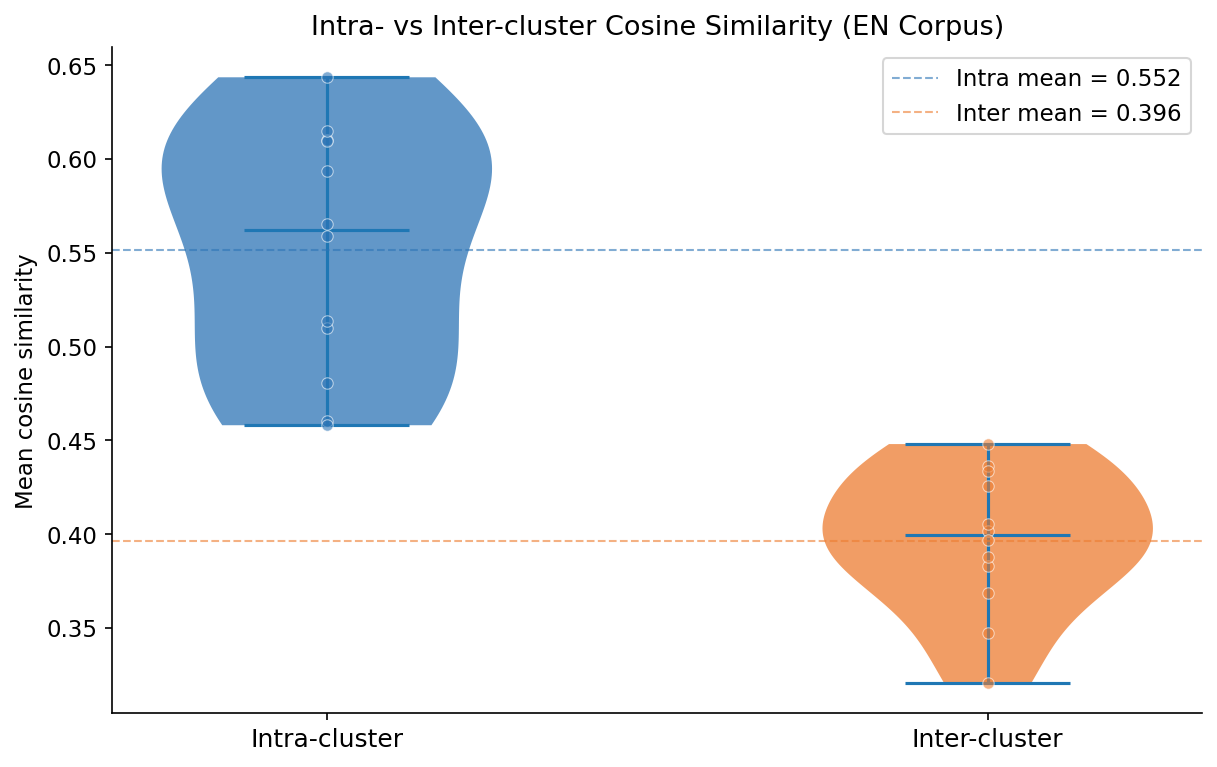

In [ ]:
X_norm     = normalize(X, norm='l2')
SAMPLE     = 80
intra_sims = []
inter_sims = []

for c in cluster_ids:
    idx_c     = np.where(labels == c)[0]
    idx_other = np.where(labels != c)[0]
    if len(idx_c) > SAMPLE:
        idx_c = np.random.choice(idx_c, SAMPLE, replace=False)
    if len(idx_other) > SAMPLE:
        idx_other = np.random.choice(idx_other, SAMPLE, replace=False)

    if len(idx_c) > 1:
        S = X_norm[idx_c] @ X_norm[idx_c].T
        intra_sims.append(float(S[np.triu_indices_from(S, k=1)].mean()))
    if len(idx_c) > 0 and len(idx_other) > 0:
        inter_sims.append(float((X_norm[idx_c] @ X_norm[idx_other].T).mean()))

mean_intra = np.mean(intra_sims)
mean_inter = np.mean(inter_sims)
print(f'Mean intra-cluster cosine similarity : {mean_intra:.4f}')
print(f'Mean inter-cluster cosine similarity : {mean_inter:.4f}')
print(f'Separation ratio (intra/inter)       : {mean_intra/mean_inter:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot([intra_sims, inter_sims], positions=[1, 2],
                      showmedians=True, showextrema=True)
parts['bodies'][0].set_facecolor('#2E75B6')
parts['bodies'][1].set_facecolor('#ED7D31')
for pc in parts['bodies']:
    pc.set_alpha(0.75)
ax.scatter([1]*len(intra_sims), intra_sims, s=30, zorder=3,
           color='#2E75B6', alpha=0.6, edgecolors='white', linewidths=0.5)
ax.scatter([2]*len(inter_sims), inter_sims, s=30, zorder=3,
           color='#ED7D31', alpha=0.6, edgecolors='white', linewidths=0.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Intra-cluster', 'Inter-cluster'], fontsize=12)
ax.set_ylabel('Mean cosine similarity')
ax.set_title('Intra- vs Inter-cluster Cosine Similarity (EN Corpus)')
ax.axhline(mean_intra, color='#2E75B6', linestyle='--', linewidth=1,
           alpha=0.6, label=f'Intra mean = {mean_intra:.3f}')
ax.axhline(mean_inter, color='#ED7D31', linestyle='--', linewidth=1,
           alpha=0.6, label=f'Inter mean = {mean_inter:.3f}')
ax.legend()
fig.savefig(PLOT_DIR / 'fig_en_intra_inter_similarity.png', bbox_inches='tight')
plt.show()

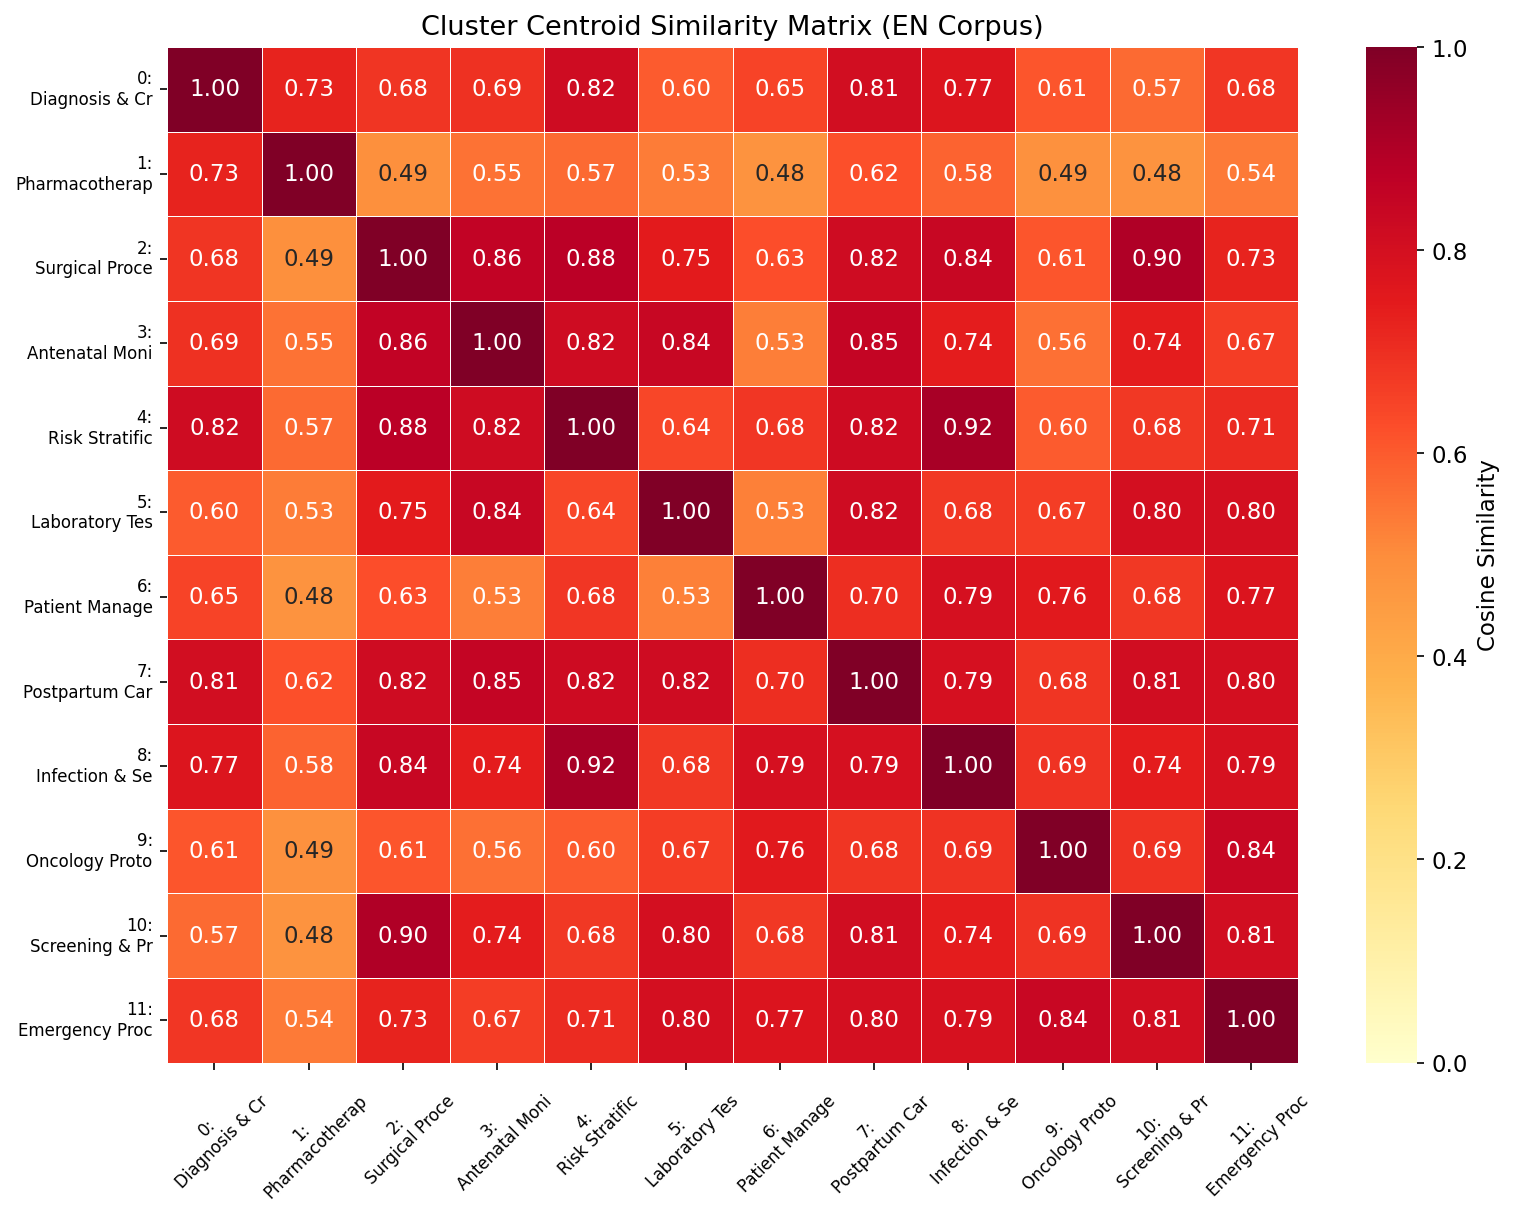

In [ ]:
centroids = np.array([X_norm[labels == c].mean(axis=0) for c in cluster_ids])
centroids = normalize(centroids, norm='l2')
C_sim     = centroids @ centroids.T

tick_labels = [f'{c}:\n{CLUSTER_LABELS.get(c,"")[:14]}' for c in cluster_ids]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(C_sim, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=tick_labels, yticklabels=tick_labels,
            vmin=0, vmax=1, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_title('Cluster Centroid Similarity Matrix (EN Corpus)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
fig.savefig(PLOT_DIR / 'fig_en_cluster_centroid_heatmap.png', bbox_inches='tight')
plt.show()

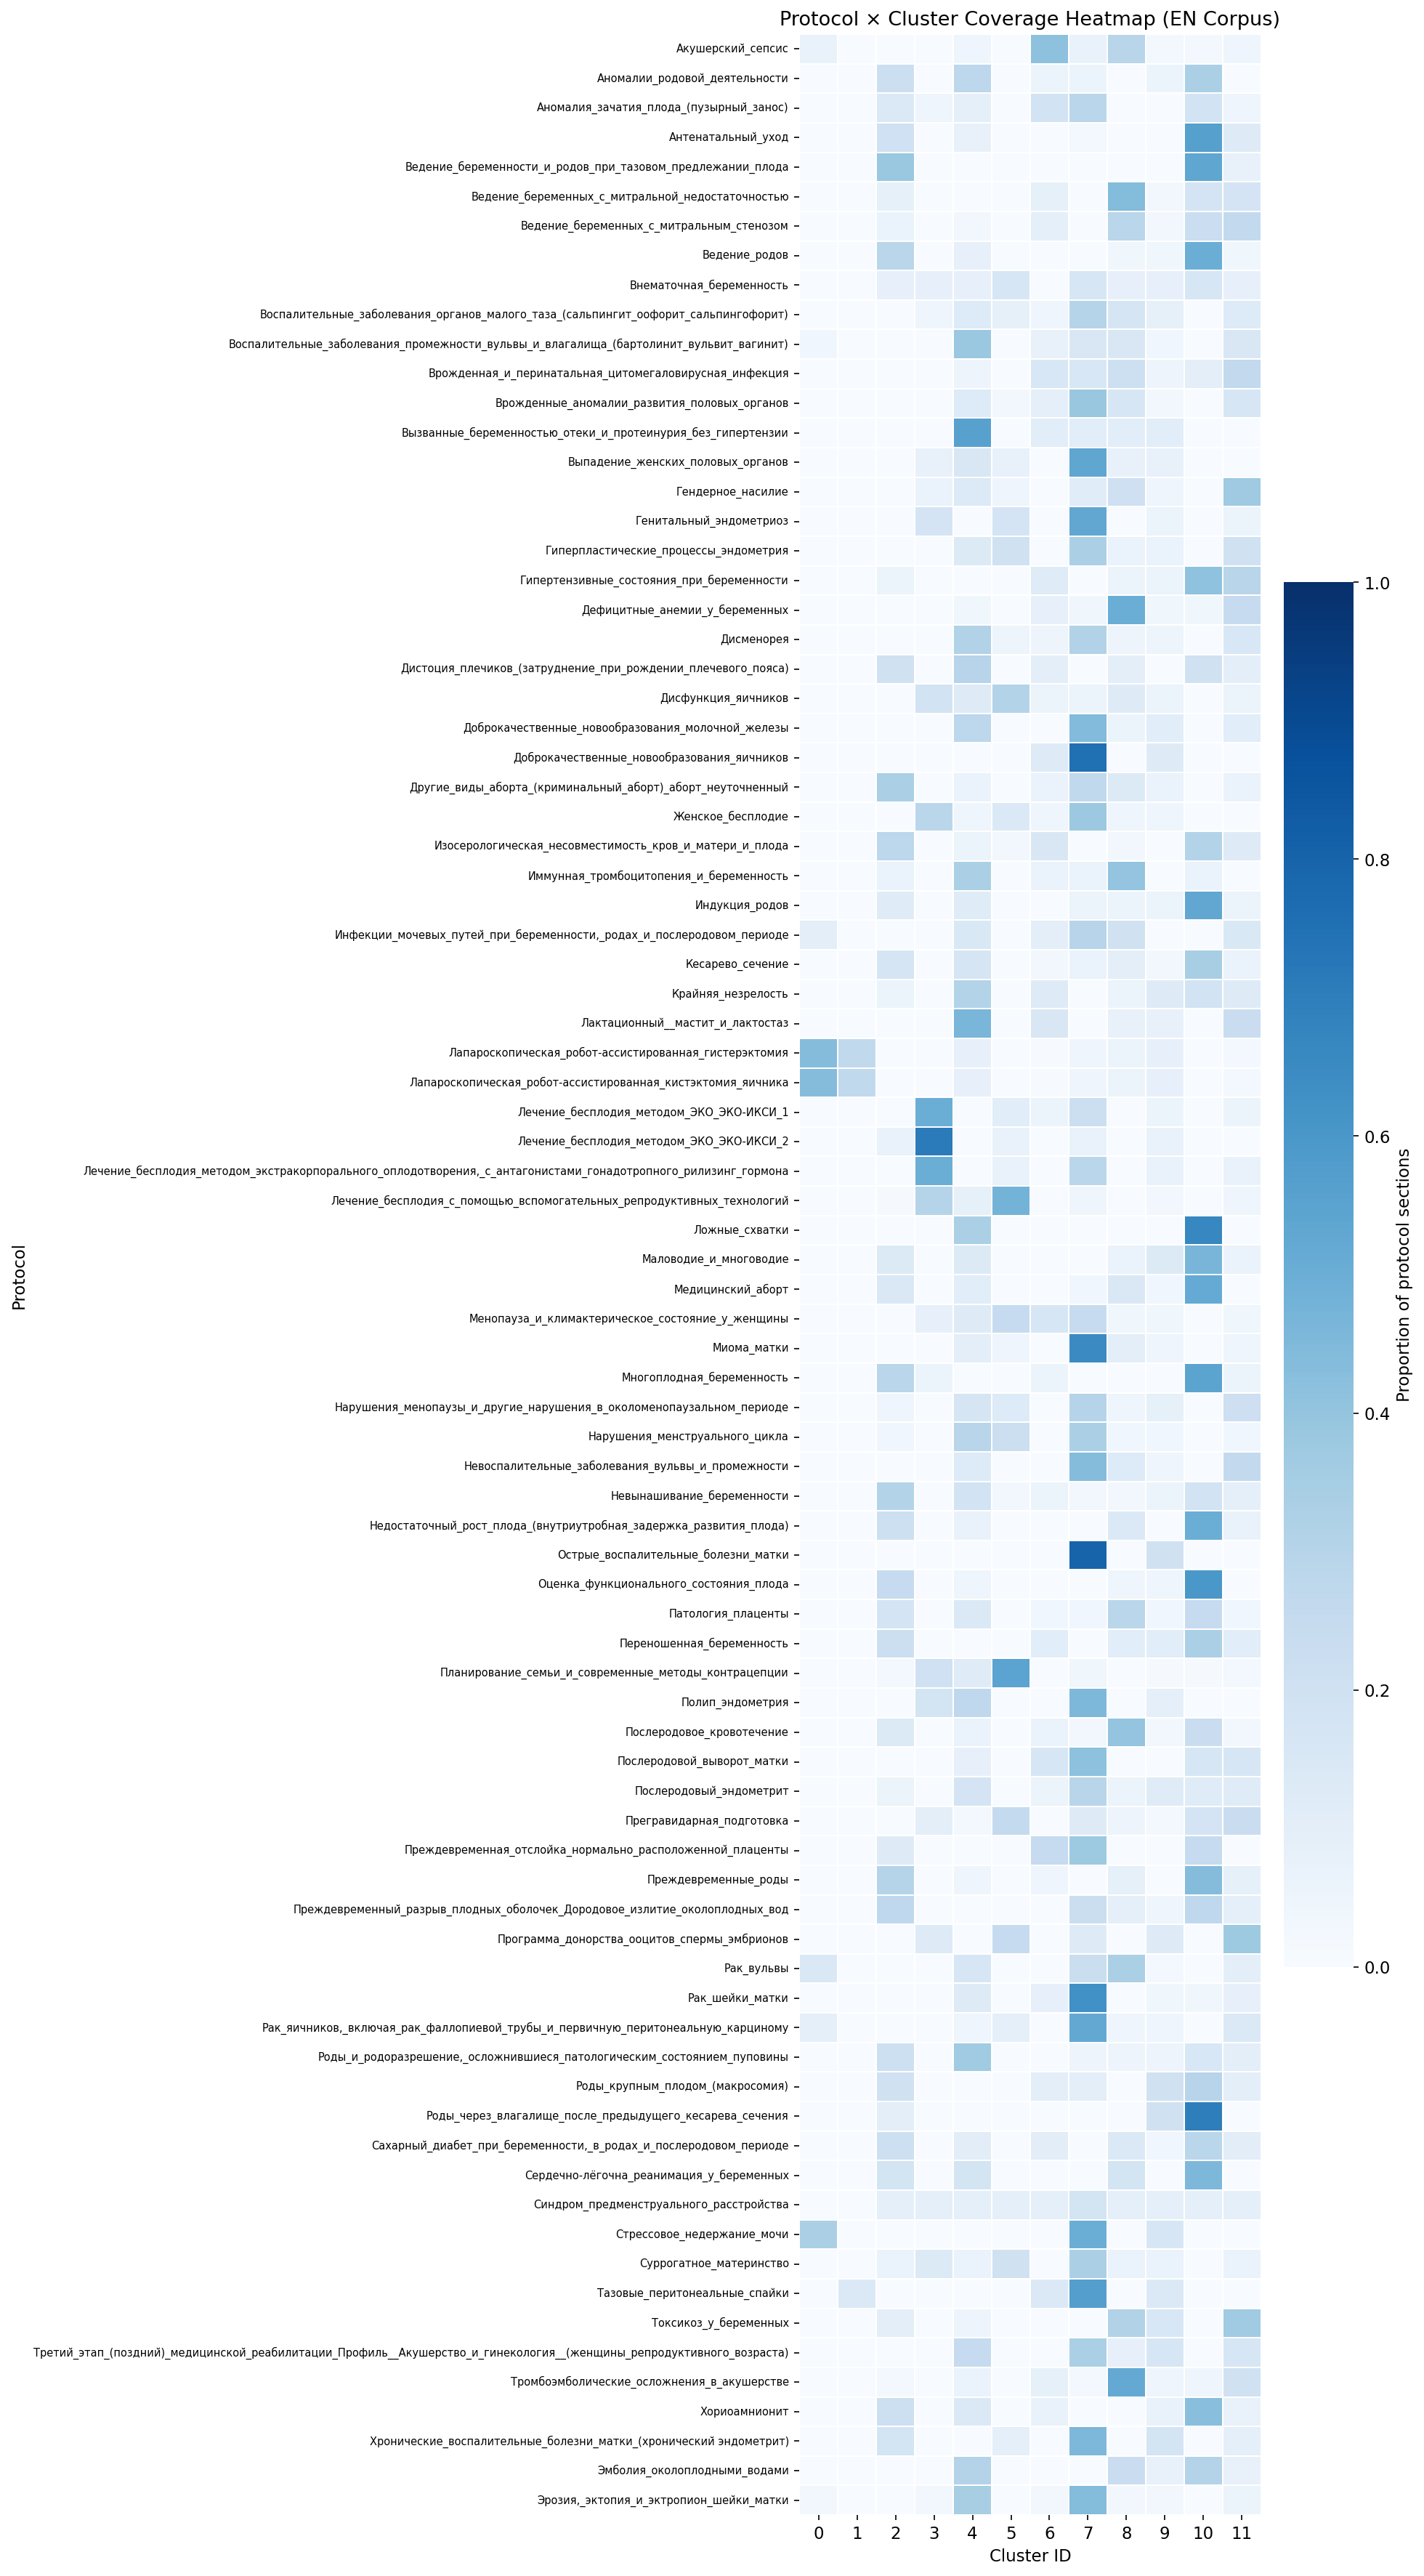

In [ ]:
coverage = (
    df.groupby(['protocol', 'cluster'])
    .size()
    .unstack(fill_value=0)
)
coverage_pct = coverage.div(coverage.sum(axis=1), axis=0).round(3)
coverage_pct = coverage_pct[coverage.sum(axis=1) >= 3]

fig, ax = plt.subplots(figsize=(13, max(6, len(coverage_pct) * 0.28)))
sns.heatmap(coverage_pct, cmap='Blues', ax=ax,
            vmin=0, vmax=1, linewidths=0.2,
            xticklabels=[str(c) for c in coverage_pct.columns],
            cbar_kws={'label': 'Proportion of protocol sections'})
ax.set_title('Protocol × Cluster Coverage Heatmap (EN Corpus)')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Protocol')
ax.tick_params(axis='y', labelsize=7)
fig.savefig(PLOT_DIR / 'fig_en_protocol_cluster_coverage.png', bbox_inches='tight')
plt.show()

## EN vs RU Corpus Comparison

In [ ]:
# ── Load RU summary ───────────────────────────────────────────────────────────
ru_summary_path = RU_EMB_DIR / 'ru_corpus_validation_summary.json'

if ru_summary_path.exists():
    with open(ru_summary_path) as f:
        ru_summary = json.load(f)
    print('RU validation summary loaded.')
else:
    print('RU summary not found — run ru_emb_thesis.ipynb first.')
    print('Using placeholder zeros for comparison.')
    ru_summary = {
        'n_sections_total': 0, 'section_chars_mean': 0, 'section_chars_median': 0,
        'n_clusters': N_CLUSTERS, 'silhouette_global': 0,
        'mean_intra_cluster_cosine': 0, 'mean_inter_cluster_cosine': 0,
        'separation_ratio': 0, 'embedding_model': RU_MODEL_NAME,
    }

RU validation summary loaded.


In [ ]:
en_summary_vals = {
    'n_protocols':                  int(df['protocol'].nunique()),
    'n_sections_total':             int(len(df)),
    'section_chars_mean':           round(float(df['section_chars'].mean()), 1),
    'section_chars_median':         round(float(df['section_chars'].median()), 1),
    'embedding_dim':                int(X.shape[1]),
    'silhouette_global':            round(float(sil_global), 4),
    'mean_intra_cluster_cosine':    round(float(mean_intra), 4),
    'mean_inter_cluster_cosine':    round(float(mean_inter), 4),
    'separation_ratio':             round(float(mean_intra / mean_inter), 4),
    'embedding_model':              EN_MODEL_NAME,
}

metrics = [
    ('Protocols',                   'n_protocols'),
    ('Total sections',              'n_sections_total'),
    ('Mean section length (chars)', 'section_chars_mean'),
    ('Median section length',       'section_chars_median'),
    ('Embedding dimension',         'embedding_dim'),
    ('Silhouette score (k=12)',     'silhouette_global'),
    ('Intra-cluster cosine sim',    'mean_intra_cluster_cosine'),
    ('Inter-cluster cosine sim',    'mean_inter_cluster_cosine'),
    ('Separation ratio',            'separation_ratio'),
]

rows = []
for label, key in metrics:
    rows.append({
        'Metric':        label,
        'EN (translated)': en_summary_vals.get(key, '—'),
        'RU (original)':   ru_summary.get(key, '—'),
    })

df_compare = pd.DataFrame(rows)
df_compare.to_csv(OUTPUT_DIR / 'en_ru_corpus_comparison.csv', index=False)

print('\n' + '='*65)
print('  EN vs RU CORPUS COMPARISON — TABLE 3.X (thesis)')
print('='*65)
display(df_compare)


  EN vs RU CORPUS COMPARISON — TABLE 3.X (thesis)


,Metric,EN (translated),RU (original)
0,Protocols,84.0000,84.0000
1,Total sections,2029.0000,2490.0000
2,Mean section length (chars),1959.6000,1515.9000
3,Median section length,849.0000,685.5000
4,Embedding dimension,768.0000,768.0000
5,Silhouette score (k=12),0.0540,0.0694
6,Intra-cluster cosine sim,0.5515,0.5800
7,Inter-cluster cosine sim,0.3963,0.3704
8,Separation ratio,1.3917,1.5658


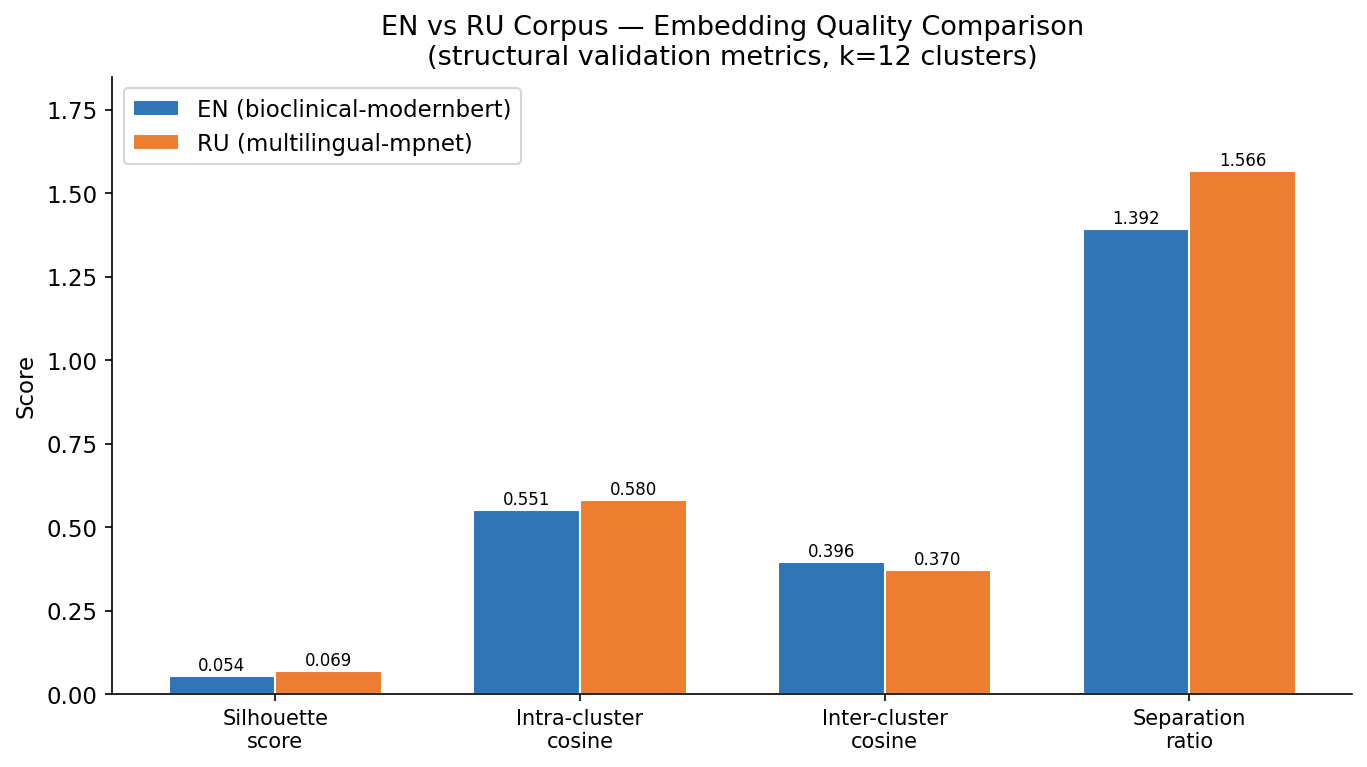

In [ ]:
compare_metrics = [
    ('Silhouette\nscore', 'silhouette_global'),
    ('Intra-cluster\ncosine', 'mean_intra_cluster_cosine'),
    ('Inter-cluster\ncosine', 'mean_inter_cluster_cosine'),
    ('Separation\nratio', 'separation_ratio'),
]

en_vals = [en_summary_vals.get(k, 0) for _, k in compare_metrics]
ru_vals = [ru_summary.get(k, 0)      for _, k in compare_metrics]
labels  = [l for l, _ in compare_metrics]

x   = np.arange(len(labels))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars_en = ax.bar(x - w/2, en_vals, w, label='EN (bioclinical-modernbert)',
                 color='#2E75B6', edgecolor='white')
bars_ru = ax.bar(x + w/2, ru_vals, w, label='RU (multilingual-mpnet)',
                 color='#ED7D31', edgecolor='white')

for bar in list(bars_en) + list(bars_ru):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Score')
ax.set_title('EN vs RU Corpus — Embedding Quality Comparison\n'
             '(structural validation metrics, k=12 clusters)')
ax.legend()
ax.set_ylim(0, max(max(en_vals), max(ru_vals)) * 1.18)
fig.savefig(PLOT_DIR / 'fig_en_ru_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
sil_en = float(sil_global)
sil_ru = float(ru_summary.get('silhouette_global', 0))
delta  = round(sil_ru - sil_en, 4)

print('Silhouette interpretation:')
print(f'  EN silhouette: {sil_en:.4f}')
print(f'  RU silhouette: {sil_ru:.4f}')
print(f'  Δ (RU - EN)  : {delta:+.4f}')
print()
if abs(delta) < 0.02:
    print('  → Difference < 0.02: EN and RU corpora show comparable cluster structure.')
    print('    This supports the validity of the translation pipeline.')
elif delta > 0:
    print('  → RU silhouette higher: RU sections cluster more tightly.')
    print('    Possible cause: Russian medical language is more formulaic.')
    print('    Note: different embedding models make direct comparison approximate.')
else:
    print('  → EN silhouette higher: translation may have increased thematic separation.')
    print('    This is expected — biomedical EN model has stronger domain focus.')

Silhouette interpretation:
  EN silhouette: 0.0540
  RU silhouette: 0.0694
  Δ (RU - EN)  : +0.0154

  → Difference < 0.02: EN and RU corpora show comparable cluster structure.
    This supports the validity of the translation pipeline.


In [ ]:
summary = {
    'n_protocols':                   int(df['protocol'].nunique()),
    'n_sections_total':              int(len(df)),
    'n_sections_mean_per_protocol':  round(float(df.groupby('protocol').size().mean()), 2),
    'n_sections_std_per_protocol':   round(float(df.groupby('protocol').size().std()),  2),
    'section_chars_mean':            round(float(df['section_chars'].mean()), 1),
    'section_chars_median':          round(float(df['section_chars'].median()), 1),
    'section_chars_std':             round(float(df['section_chars'].std()), 1),
    'embedding_dim':                 int(X.shape[1]),
    'n_clusters':                    int(N_CLUSTERS),
    'silhouette_global':             round(float(sil_global), 4),
    'silhouette_best_k':             int(best_k),
    'silhouette_best_k_score':       round(float(max(sil_scores)), 4),
    'mean_intra_cluster_cosine':     round(float(mean_intra), 4),
    'mean_inter_cluster_cosine':     round(float(mean_inter), 4),
    'separation_ratio':              round(float(mean_intra / mean_inter), 4),
    'min_chars_threshold':           int(MIN_CHARS),
    'embedding_model':               EN_MODEL_NAME,
}

summary_path = OUTPUT_DIR / 'en_corpus_validation_summary.json'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('\n' + '='*55)
print('  EN CORPUS STRUCTURAL VALIDATION — SUMMARY')
print('='*55)
for k, v in summary.items():
    print(f'  {k:<42} {v}')
print('='*55)
print(f'\nSaved: {summary_path}')


  EN CORPUS STRUCTURAL VALIDATION — SUMMARY
  n_protocols                                84
  n_sections_total                           2029
  n_sections_mean_per_protocol               24.15
  n_sections_std_per_protocol                22.69
  section_chars_mean                         1959.6
  section_chars_median                       849.0
  section_chars_std                          5420.4
  embedding_dim                              768
  n_clusters                                 12
  silhouette_global                          0.054
  silhouette_best_k                          17
  silhouette_best_k_score                    0.0586
  mean_intra_cluster_cosine                  0.5515
  mean_inter_cluster_cosine                  0.3963
  separation_ratio                           1.3917
  min_chars_threshold                        200
  embedding_model                            NeuML/bioclinical-modernbert-base-embeddings

Saved: /content/drive/MyDrive/medical_protocols/embeddin

In [ ]:
df.to_csv(OUTPUT_DIR / 'clusters_sections.csv', index=False)

cluster_summary = (
    df.groupby(['cluster', 'cluster_label'])
    .agg(
        n_sections=('section_id', 'count'),
        mean_chars=('section_chars', 'mean'),
        mean_silhouette=('silhouette_sample', 'mean'),
    )
    .reset_index()
    .sort_values('n_sections', ascending=False)
    .round(3)
)
cluster_summary.to_csv(OUTPUT_DIR / 'en_cluster_summary.csv', index=False)

print('All outputs saved:')
for f in (sorted(OUTPUT_DIR.glob('*.csv')) +
          sorted(OUTPUT_DIR.glob('*.json')) +
          sorted(OUTPUT_DIR.glob('*.npy')) +
          sorted(PLOT_DIR.glob('*.png'))):
    print(f'  {f.relative_to(OUTPUT_DIR.parent)}')

print('\nFinal cluster summary:')
display(cluster_summary)

All outputs saved:
  section_embeddings_v1/cluster_examples.csv
  section_embeddings_v1/cluster_top_titles.csv
  section_embeddings_v1/clusters_sections.csv
  section_embeddings_v1/en_cluster_summary.csv
  section_embeddings_v1/en_ru_corpus_comparison.csv
  section_embeddings_v1/en_corpus_validation_summary.json
  section_embeddings_v1/sections_en_Акушерский_сепсис.json
  section_embeddings_v1/sections_en_Аномалии_родовой_деятельности.json
  section_embeddings_v1/sections_en_Аномалия_зачатия_плода_(пузырный_занос).json
  section_embeddings_v1/sections_en_Антенатальный_уход.json
  section_embeddings_v1/sections_en_Ведение_беременности_и_родов_при_тазовом_предлежании_плода.json
  section_embeddings_v1/sections_en_Ведение_беременных_с_митральной_недостаточностью.json
  section_embeddings_v1/sections_en_Ведение_беременных_с_митральным_стенозом.json
  section_embeddings_v1/sections_en_Ведение_родов.json
  section_embeddings_v1/sections_en_Внематочная_беременность.json
  section_embeddi

,cluster,cluster_label,n_sections,mean_chars,mean_silhouette
7,7,Postpartum Care,298,1573.460,0.046
10,10,Screening & Prevention,266,2227.011,0.072
4,4,Risk Stratification,234,1712.829,0.050
8,8,Infection & Sepsis,227,1428.661,-0.002
11,11,Emergency Procedures,194,2709.845,0.007
2,2,Surgical Procedures,150,1219.653,0.039
0,0,Diagnosis & Criteria,144,3413.042,0.013
5,5,Laboratory Tests,137,1821.314,0.066
9,9,Oncology Protocols,108,2201.019,0.157
3,3,Antenatal Monitoring,96,1268.750,0.061
